In [66]:
import matplotlib.pyplot as plt
import networkx as nx
import ndlib.models.epidemics as ep
import ndlib.models.ModelConfig as mc
from bokeh.io import output_notebook, show
from bokeh.io.export import export_png
from ndlib.viz.mpl.DiffusionTrend import DiffusionTrend
from ndlib.viz.mpl.DiffusionPrevalence import DiffusionPrevalence

# choose the network model 

In [38]:
# Network Definition
g = nx.erdos_renyi_graph(1000, 0.1)

# Model Selection
model = ep.SIRModel(g)

# Configure the simulation

In [40]:
# Model Configuration 
config = mc.Configuration()

# Model Parameters
config.add_model_parameter('beta', 0.001)
config.add_model_parameter('gamma', 0.01)
config.add_model_parameter("fraction_infected", 0.05)
model.set_initial_status(config) # set the configuration to the model

# Node Configuration
# threshold = 0.25
# for i in g.nodes():
#     config.add_node_configuration("threshold", i, threshold)  #threshold probability for each node in the Erdos-Renyi graph

# Edge Configuration
# threshold = 0.25
# for i in g.nodes():
#     config.add_edge_configuration("threshold", i, threshold)

# Status Configuration (Initial Infected Nodes)
# infected_nodes = [0, 1, 2, 3, 4, 5]
# config.add_model_initial_configuration("Infected", infected_nodes) # set the initial infected nodes
# model.set_initial_status(config) # set the configuration to the model


# Excute the simulation

In [41]:
# Simulation
iterations = model.iteration_bunch(200) # bunch of 200 iterations
trends = model.build_trends(iterations) # build the trends

# Visualize the trend

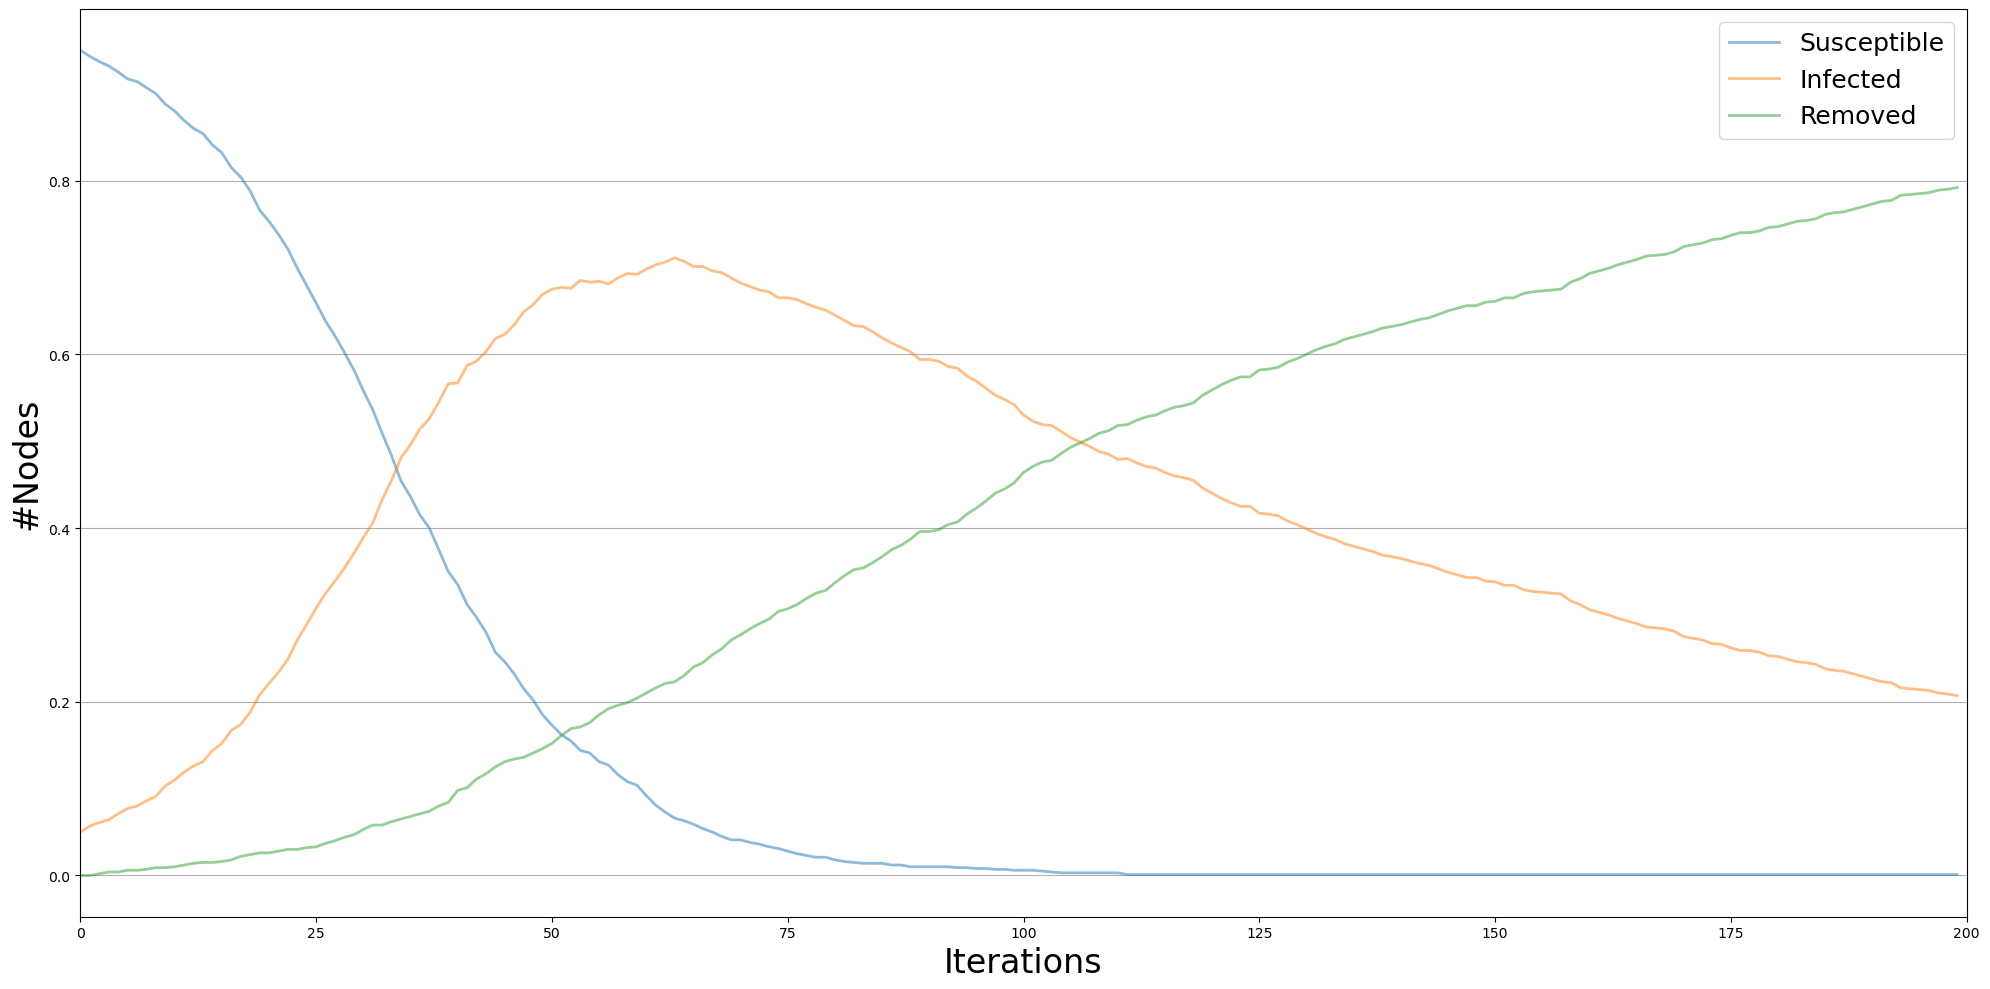

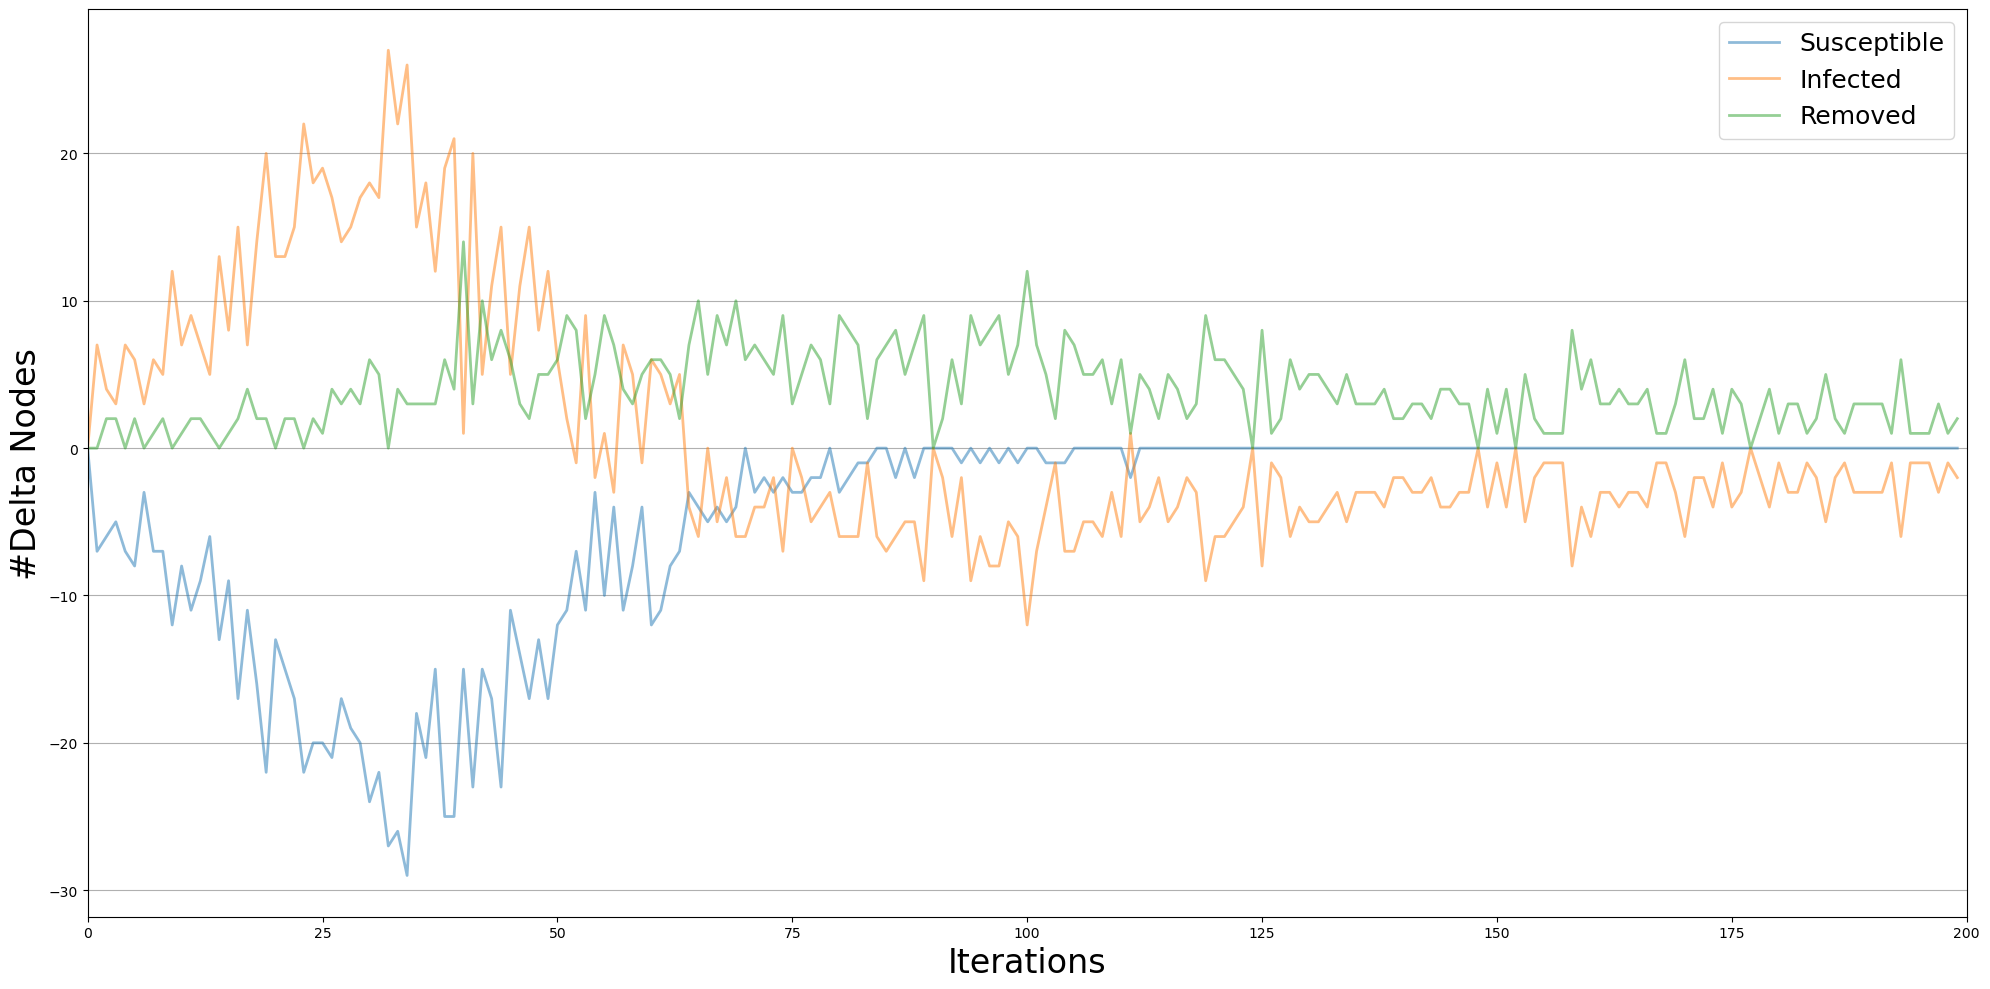

In [ ]:
# Visualize the trend
viz = DiffusionTrend(model, trends)
p = viz.plot()
plt.show(p)

# Visualize the prevalence
viz2 = DiffusionPrevalence(model, trends)
p2 = viz2.plot()
plt.show(p2)


# Visualize the real network

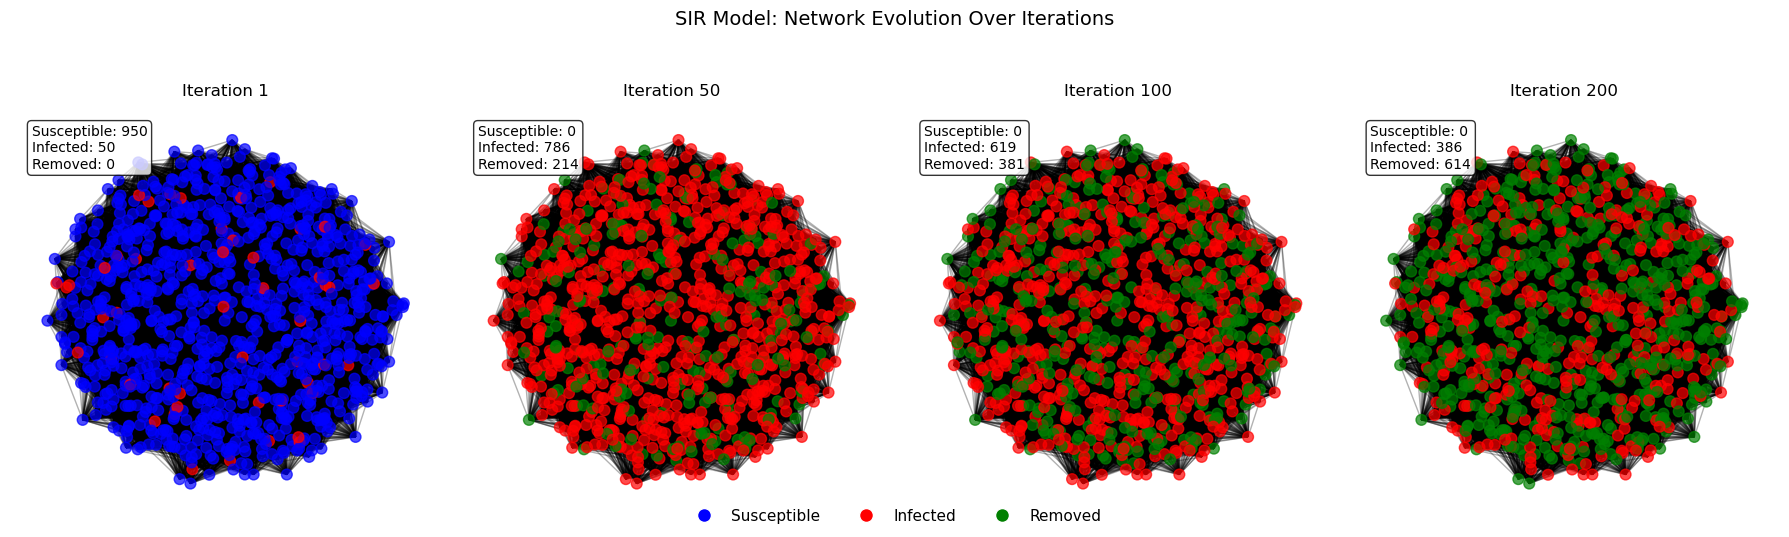

In [96]:
g = nx.erdos_renyi_graph(1000, 0.1)
sir_model = ep.SIRModel(g)
config = mc.Configuration()
config.add_model_parameter("beta", 0.01)
config.add_model_parameter("gamma", 0.005)
config.add_model_parameter("fraction_infected", 0.05)
sir_model.set_initial_status(config)

# Run simulation and reconstruct full status history
snapshots = []                            # list of full status dicts per iteration
current_status = sir_model.status.copy()  # start with initial full state
snapshots.append(current_status.copy())

for i in range(200):
    iteration = sir_model.iteration()     # perform one iteration
    for node, new_state in iteration['status'].items():  
        current_status[node] = new_state  # update only changed nodes
    snapshots.append(current_status.copy())

# Choose snapshots to plot
selected_steps = [1, 50, 100, 200]

# Visualization
status_labels = {0: 'Susceptible', 1: 'Infected', 2: 'Removed'}
status_colors = {0: 'blue', 1: 'red', 2: 'green'}
pos = nx.spring_layout(g, seed=42)

fig, axs = plt.subplots(1, len(selected_steps), figsize=(18, 5))

for ax, step in zip(axs, selected_steps):
    snap = snapshots[step]
    node_colors = [status_colors[snap[node]] for node in g.nodes()]

    # --- Plot the network ---
    nx.draw_networkx_nodes(g, pos, node_color=node_colors, node_size=60, alpha=0.7, ax=ax)
    nx.draw_networkx_edges(g, pos, alpha=0.3, ax=ax)

    # --- Count nodes per status ---
    counts = {s: list(snap.values()).count(s) for s in [0, 1, 2]}
    text = "\n".join([f"{status_labels[s]}: {counts[s]}" for s in [0, 1, 2]])

    ax.set_title(f"Iteration {step}", fontsize=12)
    ax.text(0.05, 0.95, text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    ax.axis("off")

# Add a global color legend (outside subplots)
handles = [plt.Line2D([0], [0], marker='o', color='w', label=label, markerfacecolor=color, markersize=10) for label, color in zip(status_labels.values(), status_colors.values())]

fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=11, frameon=False)
plt.suptitle("SIR Model: Network Evolution Over Iterations", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()
